# 03 · Customer Segmentation (RFM) & Churn

**Goals**
1. Segment customers into **VIP, Loyal, Potential, At Risk and Lost** with rules derived from real behaviour.
2. Estimate each customer's **probability of not buying again** (churn) and explain the main risk factors.

Results come from the active model runs in PostgreSQL (`python -m machine_learning`). Code:
`machine_learning/segmentation/rfm.py` and `machine_learning/churn/model.py`.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # project root
warnings.filterwarnings("ignore", category=UserWarning)

import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

from nexus_nb import AXIS, GRID, INK, MUTED_FILL, SEQUENTIAL_BLUE, SERIES, brl, query

period = query("SELECT * FROM analytics.v_reporting_period").iloc[0]

runs = query("SELECT model_name, algorithm, trained_at, params, metrics FROM ml.model_runs WHERE is_active")
seg_run = runs.set_index("model_name").loc["rfm_segmentation"]
churn_run = runs.set_index("model_name").loc["churn"]
period.to_frame("value")

,value
data_start,2017-01-14
data_end,2018-08-23
first_month,2017-02-01
last_month,2018-07-01
reference_date,2018-08-24


## Part 1 · RFM segmentation

### 1.1 Why the thresholds are not arbitrary

Recency only means something relative to how often customers actually come back. The segmentation
therefore uses the **real gaps between consecutive purchases** of repeat customers. Same-day orders
are excluded, because they are split baskets rather than returns.

- Beyond the **75th percentile** of those gaps, a customer is past the window in which three quarters
  of repeat purchases happen: **At Risk**.
- Beyond the **90th percentile**, they are **Lost**.

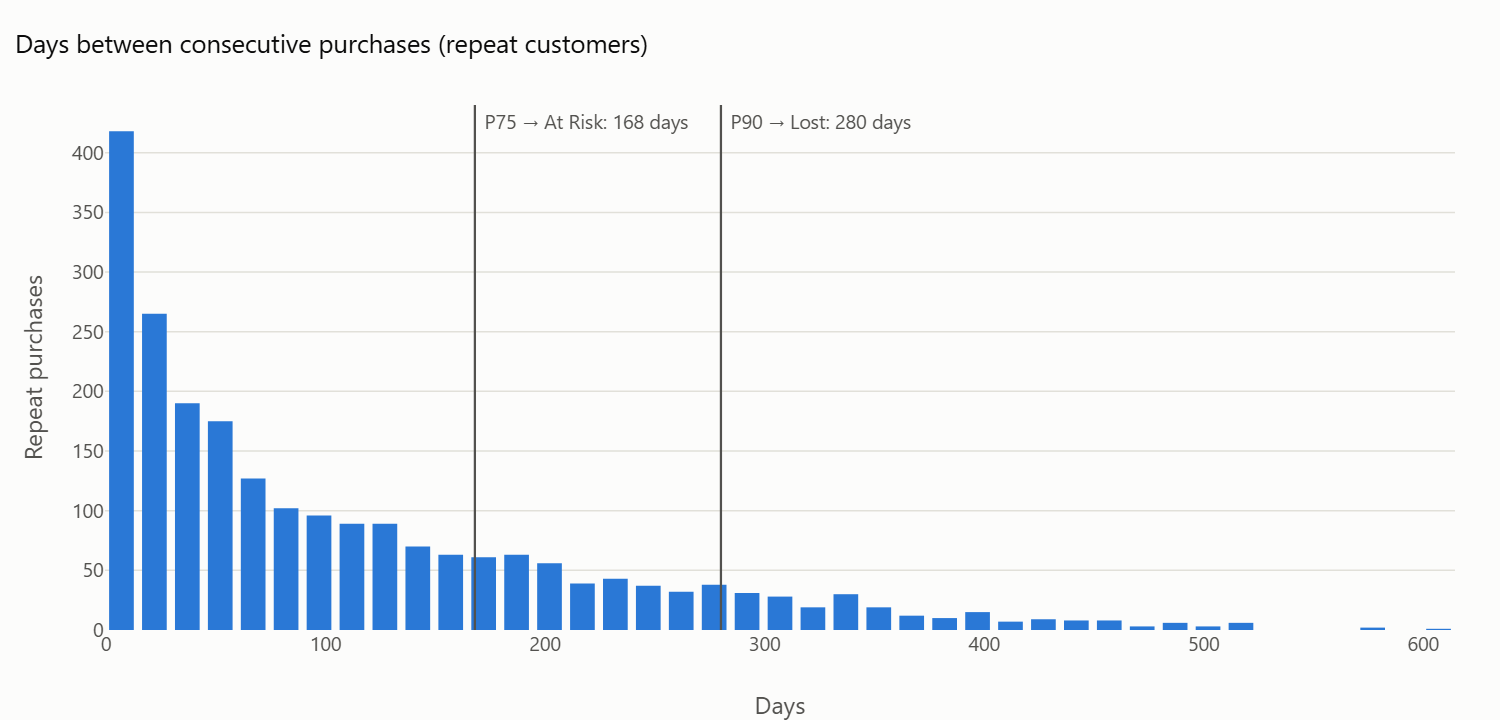

,value
p50,69.00
p75,168.00
p90,280.10
n_gaps,"2,270.00"


In [2]:
gaps = query("""
    WITH p AS (
        SELECT purchased_at::date - lag(purchased_at::date) OVER (PARTITION BY customer_key ORDER BY purchased_at) AS gap
        FROM analytics.v_orders
        WHERE is_valid_sale AND purchase_date < (SELECT reference_date FROM analytics.v_reporting_period))
    SELECT gap FROM p WHERE gap > 0
""")["gap"]
gap = seg_run["params"]["repurchase_gap_days"]

fig = go.Figure(go.Histogram(x=gaps, xbins=dict(size=15), marker_color=SERIES[0], name="Repeat purchases",
                             hovertemplate="%{x} days: %{y} purchases<extra></extra>"))
for q, label in [("p75", "P75 → At Risk"), ("p90", "P90 → Lost")]:
    fig.add_vline(x=gap[q], line=dict(color=INK["secondary"], width=1.5))
    fig.add_annotation(x=gap[q], y=1, yref="paper", text=f"{label}: {gap[q]:.0f} days", showarrow=False,
                       xanchor="left", xshift=4, font=dict(color=INK["secondary"]))
fig.update_layout(title="Days between consecutive purchases (repeat customers)", xaxis_title="Days",
                  yaxis_title="Repeat purchases", showlegend=False)
fig.show()
pd.Series(gap).to_frame("value")

### 1.2 Scores and rules

| Score | How it is computed |
|---|---|
| **R** (1–5) | Quintiles of recency. The most recent fifth scores 5. |
| **F** (1–5) | Quintiles are impossible because ~97% of customers have one order, so F uses the actual counts: 1 order → 1, 2 → 3, 3 → 4, 4+ → 5. |
| **M** (1–5) | Quintiles of lifetime revenue. The top fifth scores 5. |

Rules are evaluated in order, and the first match wins:

In [3]:
summary = query("SELECT * FROM analytics.v_segment_summary ORDER BY display_order")
summary[["segment", "rule", "customers", "customer_share", "revenue", "revenue_share",
         "avg_revenue_per_customer", "avg_orders", "avg_recency_days"]]

,segment,rule,customers,customer_share,revenue,revenue_share,avg_revenue_per_customer,avg_orders,avg_recency_days
0,VIP,"2+ orders, top-20% spend (M = 5) and last purc...",625,0.01,"257,856.22",0.02,412.57,2.25,80.00
1,Loyal,2+ orders and last purchase within 168 days,565,0.01,"62,247.04",0.00,110.17,2.05,85.00
2,Potential,"1 order, last purchase within 168 days",35557,0.38,"5,015,750.71",0.37,141.06,1.00,84.00
3,At Risk,Last purchase between 168 and 280 days ago,25360,0.27,"3,442,705.56",0.26,135.75,1.03,226.00
4,Lost,No purchase for more than 280 days,32544,0.34,"4,676,874.52",0.35,143.71,1.03,410.00


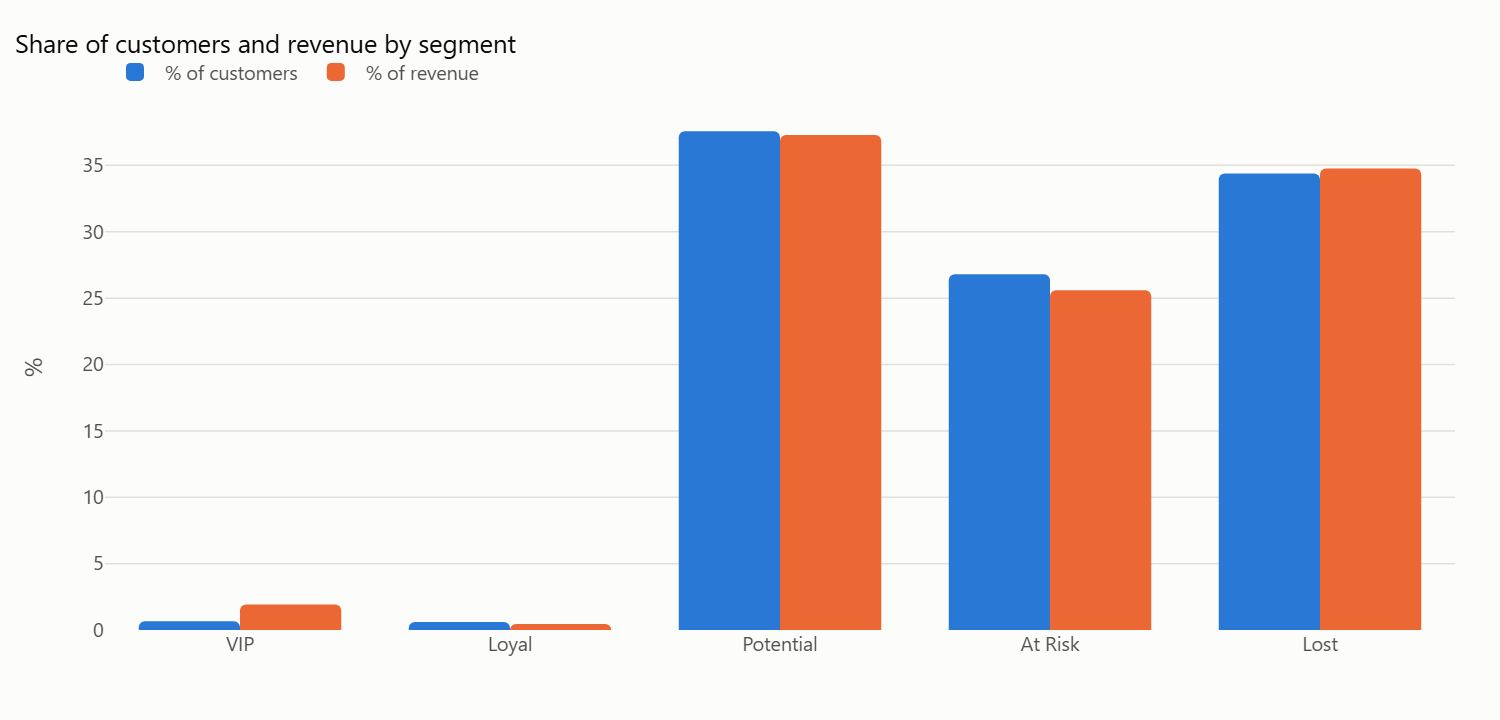

In [4]:
fig = go.Figure()
fig.add_bar(x=summary["segment"], y=summary["customer_share"] * 100, name="% of customers", marker_color=SERIES[0],
            hovertemplate="%{x}: %{y:.1f}% of customers<extra></extra>")
fig.add_bar(x=summary["segment"], y=summary["revenue_share"] * 100, name="% of revenue", marker_color=SERIES[1],
            hovertemplate="%{x}: %{y:.1f}% of revenue<extra></extra>")
fig.update_layout(title="Share of customers and revenue by segment", barmode="group", yaxis_title="%")
fig.show()

### 1.3 Business recommendations per segment

In [5]:
pd.set_option("display.max_colwidth", None)
summary[["segment", "description", "recommendation"]].style.hide(axis="index")

segment,description,recommendation
VIP,Repeat buyers with the highest spend who are still active.,"Protect them: priority support, early access and loyalty rewards. Monitor their delivery experience closely, since late deliveries strongly reduce satisfaction."
Loyal,Customers who have already come back at least once and are still active.,Grow the basket: cross-sell complementary categories and offer incentives on the next purchase.
Potential,Recent one-time buyers still inside the window in which 75% of repeat purchases happen (168 days).,Convert to a second purchase: post-delivery follow-up and a targeted voucher before day 168.
At Risk,Customers past the window of 75% of observed repeat purchases.,Win back now with a personalised offer based on the last category bought. Check whether their last order had a delivery or review problem.
Lost,Customers beyond the window in which 90% of observed repeat purchases happen.,Use only low-cost reactivation (e-mail campaigns). Do not spend acquisition-level budget on them.


### 1.4 Sanity check against an unsupervised alternative

Would K-Means find better groups? K-Means (k = 5) runs on standardised log-R, log-F and log-M
(a 20,000-customer sample), and both partitions are compared with the **silhouette score**, which
measures how compact and separated the groups are (−1 to 1, higher is better).

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

seg = query("SELECT customer_key, recency_days, frequency, monetary, segment FROM analytics.v_customer_segments")
sample = seg.sample(20_000, random_state=42)
X = StandardScaler().fit_transform(np.log1p(sample[["recency_days", "frequency", "monetary"]]))
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X)
sil = pd.Series({
    "Rule-based RFM segments": silhouette_score(X, sample["segment"]),
    "K-Means (k=5)": silhouette_score(X, kmeans.labels_),
}).to_frame("silhouette")
display(sil)
pd.crosstab(sample["segment"], kmeans.labels_, rownames=["rule segment"], colnames=["k-means cluster"])

,silhouette
Rule-based RFM segments,0.10
K-Means (k=5),0.35


k-means cluster,0,1,2,3,4
rule segment,,,,,
At Risk,1745,0,165,887,2571
Lost,2053,0,186,1165,3556
Loyal,0,0,130,0,0
Potential,1532,2964,0,1160,1758
VIP,0,0,128,0,0


K-Means optimises geometric separation. It usually scores higher on silhouette, but its clusters have
no business meaning and change between runs. The rule-based segments trade some separation for
labels that marketing can act on, and for thresholds grounded in how customers actually return.
The crosstab shows where the two approaches agree.

## Part 2 · Churn prediction

### 2.1 Definition

A customer **churns** at a cut-off date if they make **no purchase in the following 180 days**.
Three snapshots are used, so no future information reaches the training data:

| Snapshot | Use |
|---|---|
| Train cut-off (reference − 360 days) | Model selection with 5-fold stratified cross-validation |
| Test cut-off (reference − 180 days) | **Out-of-time** evaluation: a later period the model never saw |
| Reference date | Final model (refit on the test snapshot) scores every customer |

Features only use what was known at the cut-off. For example, a review written after the cut-off
is ignored.

In [7]:
p = churn_run["params"]; m = churn_run["metrics"]
pd.Series({"horizon (days)": p["horizon_days"], "train cut-off": p["train_cutoff"], "test cut-off": p["test_cutoff"],
           "return rate in test period": f"{m['test_return_rate']:.2%}", "selected model": m["selected_model"],
           "decision threshold, P(return) ≥": round(p["threshold_p_return"], 4),
           "features": ", ".join(p["features"])}).to_frame("value")

,value
horizon (days),180
train cut-off,2017-08-29
test cut-off,2018-02-25
return rate in test period,1.19%
selected model,Logistic regression
"decision threshold, P(return) ≥",0.04
features,"recency_days, tenure_days, frequency, monetary, avg_order_value, avg_items_per_order, freight_ratio, max_installments, late_share, avg_delivery_days, avg_review, has_review, last_review, last_order_late, paid_boleto_share, paid_voucher_share, region_norte, region_nordeste, region_centro_oeste, region_sudeste, region_sul"


### 2.2 What each metric means

| Metric | Meaning here |
|---|---|
| **ROC-AUC** | Probability that a random customer who returned gets a higher return score than one who churned. 0.5 = random, 1 = perfect. It does not depend on the threshold, so it is the selection metric. |
| **PR-AUC (returning)** | Average precision when hunting for the rare returning customers. Compare it with the base rate (share who actually return): a random model scores the base rate. |
| **Precision** | Of the customers predicted in a class, the share that truly belong to it. |
| **Recall** | Of the customers truly in a class, the share the model found. |
| **F1** | Harmonic mean of precision and recall. |
| **Brier score** | Mean squared error of the probabilities (lower is better). It checks that the probabilities are usable as probabilities. |
| **Confusion matrix** | Counts of correct and incorrect predictions for each class. |

**Accuracy is misleading here.** Almost everyone churns, so "predict churn for everybody" is ~99% accurate
while finding nobody worth retaining. That trivial baseline is reported below for comparison.

In [8]:
ev = query("SELECT candidate, split, metric, value FROM analytics.v_model_evaluations WHERE model_name = 'churn'")
ranking = ev[ev["metric"].isin(["roc_auc", "pr_auc_returning", "brier"])].pivot_table(
    index="candidate", columns=["split", "metric"], values="value")
ranking.round(4)

split                  cv_train                          out_of_time_test  \
metric                    brier pr_auc_returning roc_auc            brier   
candidate                                                                   
Baseline: recency only      NaN              NaN     NaN              NaN   
Logistic regression        0.02             0.04    0.59             0.01   
Random forest              0.02             0.03    0.57             0.01   
XGBoost                    0.02             0.03    0.58             0.01   

split                                            
metric                 pr_auc_returning roc_auc  
candidate                                        
Baseline: recency only              NaN    0.57  
Logistic regression                0.04    0.61  
Random forest                      0.02    0.60  
XGBoost                            0.02    0.58

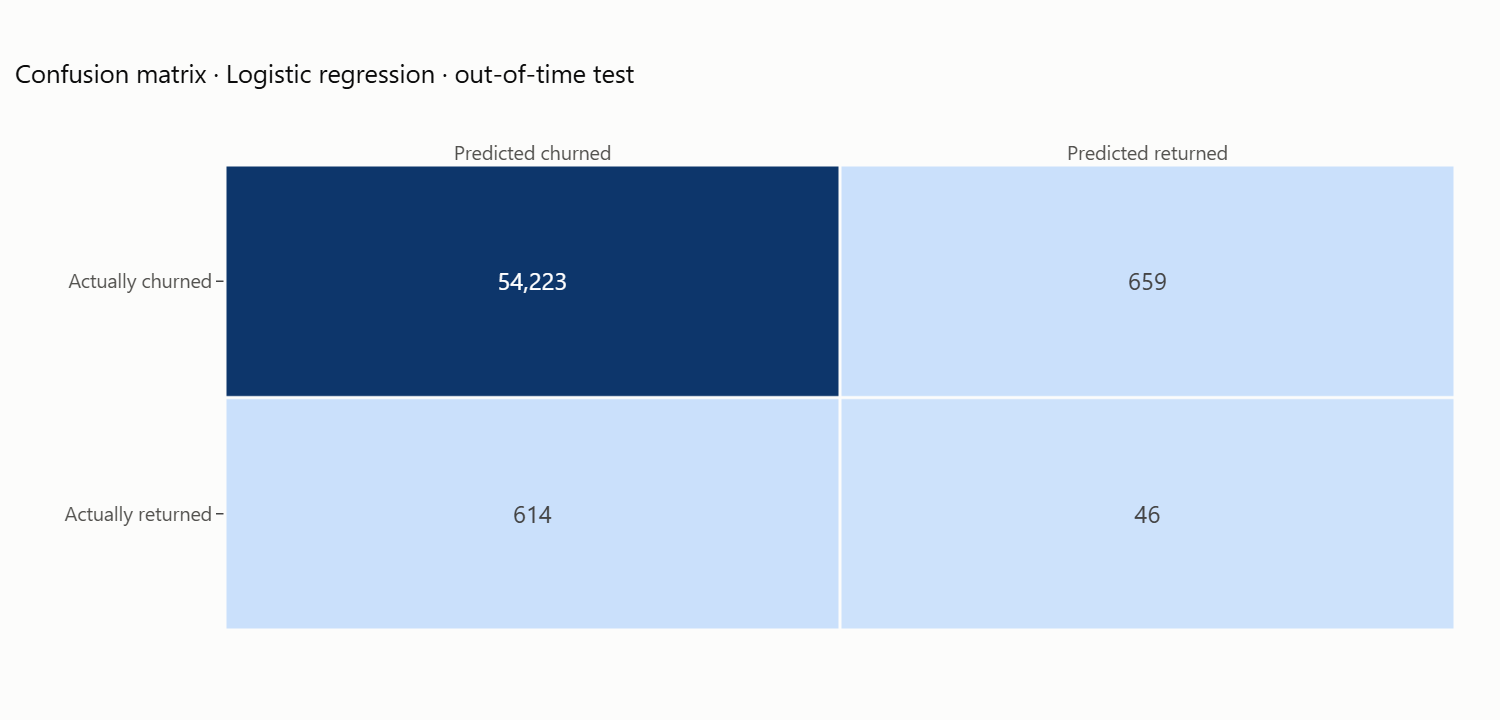

,out-of-time test
metric,
precision_churn,0.99
recall_churn,0.99
f1_churn,0.99
precision_returning,0.07
recall_returning,0.07
f1_returning,0.07
accuracy,0.98


In [9]:
test = ev[(ev["split"] == "out_of_time_test") & (ev["candidate"] == m["selected_model"])].set_index("metric")["value"]
cm = np.array([[test["tp"], test["fn"]], [test["fp"], test["tn"]]])   # rows: actual churn / actual returned
labels = ["Churned", "Returned"]
fig = go.Figure(go.Heatmap(z=cm, x=[f"Predicted {l.lower()}" for l in labels], y=[f"Actually {l.lower()}" for l in labels],
                           colorscale=SEQUENTIAL_BLUE, showscale=False, xgap=2, ygap=2,
                           text=[[f"{v:,.0f}" for v in row] for row in cm], texttemplate="%{text}",
                           textfont=dict(size=16), hovertemplate="%{y}, %{x}: %{z:,.0f}<extra></extra>"))
fig.update_layout(title=f"Confusion matrix · {m['selected_model']} · out-of-time test", height=380,
                  yaxis=dict(autorange="reversed", showgrid=False), xaxis=dict(side="top"), margin=dict(t=110, l=150))
fig.show()
test[["precision_churn", "recall_churn", "f1_churn", "precision_returning", "recall_returning", "f1_returning",
      "accuracy"]].round(4).to_frame("out-of-time test")

### 2.3 Is the model useful? Lift by decile

A modest ROC-AUC can still be useful if the top-ranked customers return much more often than average.
The selected model is refit on the train snapshot, and the out-of-time test customers are ranked into
deciles by predicted return probability.

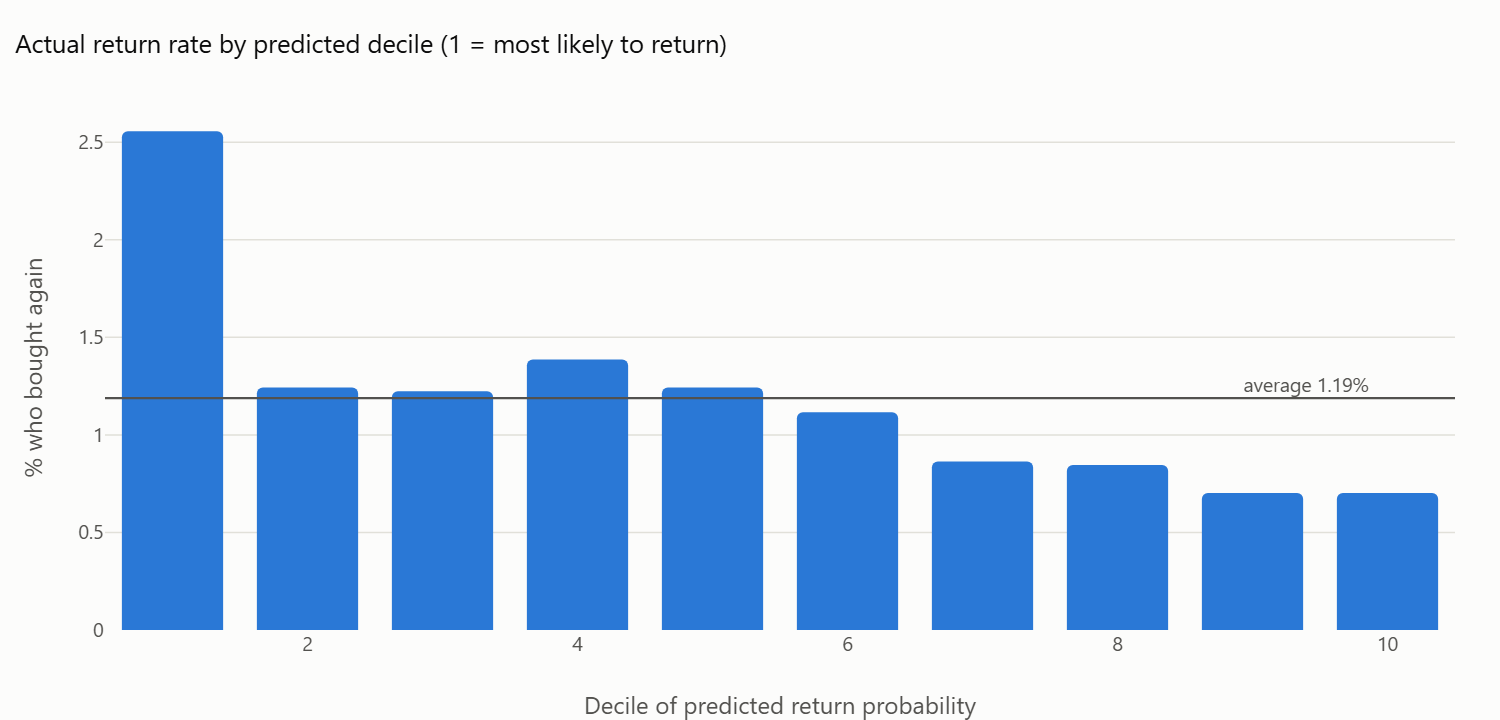

,customers,return_rate,lift_vs_average
decile,,,
1,5555,0.03,2.15
2,5554,0.01,1.05
3,5554,0.01,1.03
4,5554,0.01,1.17
5,5554,0.01,1.05
6,5554,0.01,0.94
7,5554,0.01,0.73
8,5554,0.01,0.71
9,5554,0.01,0.59


In [10]:
from machine_learning.churn import model as churn

history = churn.load_history()
t_train, t_test = pd.Timestamp(p["train_cutoff"]), pd.Timestamp(p["test_cutoff"])
X_tr = churn.build_features(history, t_train); y_tr = churn.build_labels(history, X_tr.index, t_train)
X_te = churn.build_features(history, t_test); y_te = churn.build_labels(history, X_te.index, t_test)
clf = churn.candidates()[m["selected_model"]].fit(X_tr, y_tr)
p_te = clf.predict_proba(X_te)[:, 1]

deciles = pd.DataFrame({"returned": y_te.to_numpy(), "score": p_te})
deciles["decile"] = pd.qcut(deciles["score"].rank(method="first", ascending=False), 10, labels=range(1, 11))
lift = deciles.groupby("decile", observed=True)["returned"].agg(["size", "mean"]).rename(
    columns={"size": "customers", "mean": "return_rate"})
lift["lift_vs_average"] = lift["return_rate"] / y_te.mean()

fig = go.Figure(go.Bar(x=lift.index.astype(str), y=lift["return_rate"] * 100, marker_color=SERIES[0],
                       hovertemplate="Decile %{x}: %{y:.2f}% returned<extra></extra>"))
fig.add_hline(y=y_te.mean() * 100, line=dict(color=INK["secondary"], width=1.5))
fig.add_annotation(x=9.4, y=y_te.mean() * 100, text=f"average {y_te.mean():.2%}", showarrow=False, yshift=10,
                   font=dict(color=INK["secondary"]))
fig.update_layout(title="Actual return rate by predicted decile (1 = most likely to return)",
                  xaxis_title="Decile of predicted return probability", yaxis_title="% who bought again")
fig.show()
lift.round(4)

### 2.4 What drives the risk?

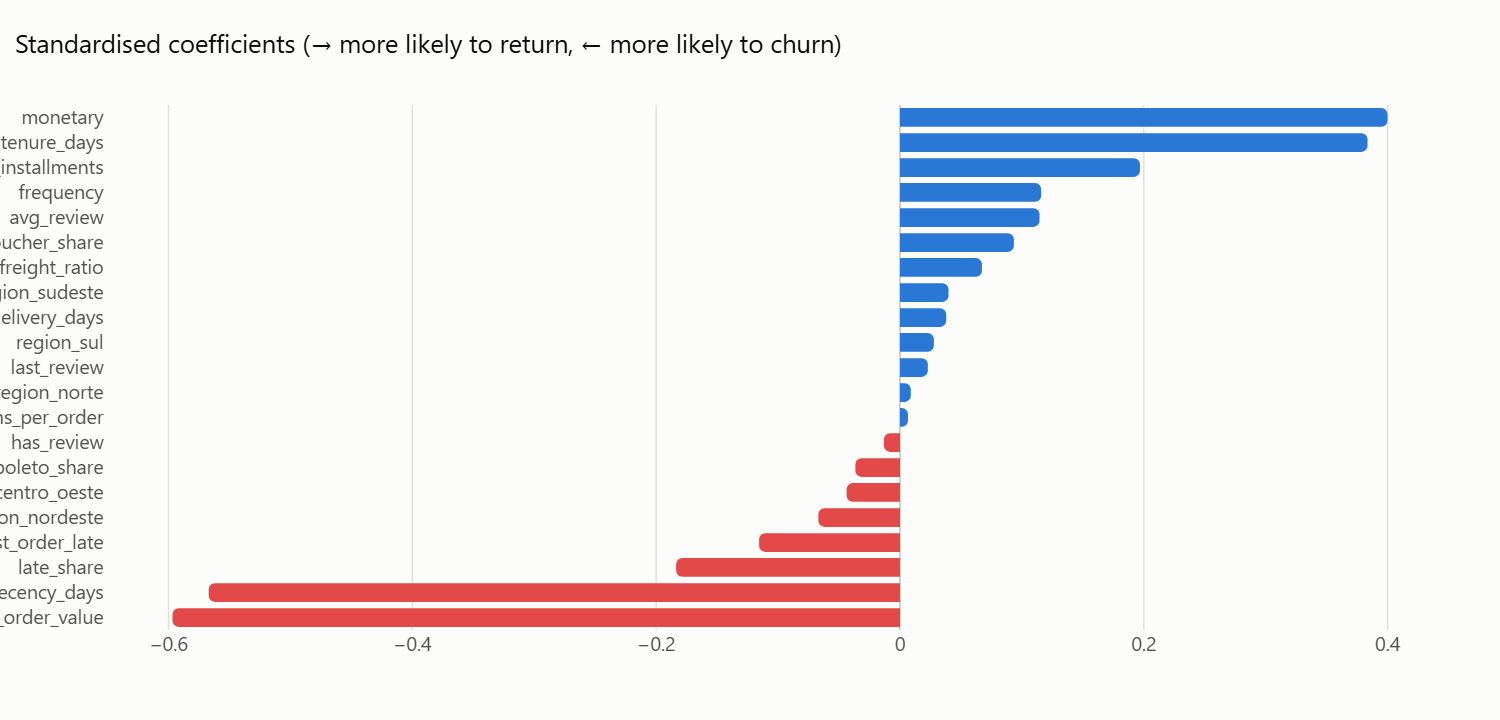

,share of high-risk customers' top factors
top_factors,
recency_days,0.44
last_review,0.17
region_nordeste,0.12
avg_order_value,0.12
avg_delivery_days,0.10
tenure_days,0.05
region_sudeste,0.01
monetary,0.00


In [11]:
if m["selected_model"] == "Logistic regression":
    lr = clf.named_steps["logisticregression"]
    coefs = pd.Series(lr.coef_[0], index=X_tr.columns).sort_values()
    colors = [SERIES[7] if c < 0 else SERIES[0] for c in coefs]
    fig = go.Figure(go.Bar(x=coefs, y=coefs.index, orientation="h", marker_color=colors,
                           hovertemplate="%{y}: %{x:+.3f}<extra></extra>"))
    fig.update_layout(title="Standardised coefficients (→ more likely to return, ← more likely to churn)",
                      height=560, xaxis=dict(zeroline=True, zerolinecolor=AXIS, showgrid=True, gridcolor=GRID),
                      yaxis=dict(showgrid=False))
    fig.show()

scores = query("SELECT customer_key, churn_probability, risk_band, top_factors, segment FROM analytics.v_churn_scores")
factors = scores.loc[scores["risk_band"] == "High", "top_factors"].explode().dropna()
factor_freq = factors.map(lambda f: f["feature"]).value_counts(normalize=True).head(8)
factor_freq.rename("share of high-risk customers' top factors").to_frame()

In [12]:
# Five highest-risk customers among the most valuable (VIP / Loyal): who to call first.
top = scores[scores["segment"].isin(["VIP", "Loyal"])].nlargest(5, "churn_probability")
top.assign(risk_factors=top["top_factors"].map(lambda fs: " · ".join(f["description"] for f in fs)))[
    ["customer_key", "segment", "churn_probability", "risk_band", "risk_factors"]]

,customer_key,segment,churn_probability,risk_band,risk_factors
19114,19526,VIP,0.99,Medium,"Average order R$ 1,119.21 · Customer for 96 days"
27981,28557,VIP,0.99,Medium,"Average order R$ 1,054.00 · Customer for 136 days"
70027,71195,VIP,0.99,Medium,Average order R$ 798.90 · Lives in the Nordeste region · Customer for 105 days
73730,74936,VIP,0.99,Medium,Average order R$ 384.95 · Lives in the Nordeste region · Deliveries took 34 days on average
71054,72230,VIP,0.99,Low,Deliveries took 43 days on average · Last review 1 stars · Lives in the Nordeste region


## 3. Findings

Generated from the results above.

In [13]:
lost, potential = summary.set_index("segment").loc["Lost"], summary.set_index("segment").loc["Potential"]
vip_loyal = summary[summary["segment"].isin(["VIP", "Loyal"])]
rows = ranking.xs("out_of_time_test", axis=1, level=0)
baseline_auc = ev[(ev["candidate"] == "Baseline: recency only") & (ev["metric"] == "roc_auc")]["value"].iloc[0]
display(Markdown(f"""
1. **Repeat purchases follow a long cycle.** 75% of returns happen within **{gap['p75']:.0f} days** and 90% within
   **{gap['p90']:.0f} days**. These are the At-Risk and Lost boundaries.
2. **The customer base is mostly one-time buyers.** VIP and Loyal together are {vip_loyal['customer_share'].sum():.1%} of customers but
   {vip_loyal['revenue_share'].sum():.1%} of revenue. {lost['customer_share']:.1%} of customers are already Lost, and {potential['customer_share']:.1%}
   are recent one-time buyers (**Potential**). Converting them to a second purchase is the largest lever.
3. **Churn is hard to predict from transactional history alone.** The selected model ({m['selected_model']}) reaches ROC-AUC
   **{m['test_roc_auc']:.3f}** on a later period it never saw, vs {baseline_auc:.3f} for a recency-only rule and 0.5 for random.
   PR-AUC for returning customers is {rows.loc[m['selected_model'], 'pr_auc_returning']:.3f} vs a base rate of {y_te.mean():.3f}.
4. **It is still useful for targeting.** Customers in the top decile return at **{lift['return_rate'].iloc[0]:.2%}**,
   {lift['lift_vs_average'].iloc[0]:.1f}× the average, so a retention campaign aimed at them reaches far more
   likely buyers than a random one.
5. **Accuracy would mislead.** Predicting "everyone churns" gives {ev[(ev['candidate'] == 'Baseline: always churn') & (ev['metric'] == 'accuracy')]['value'].iloc[0]:.1%}
   accuracy while identifying zero returning customers. That is why ROC-AUC, PR-AUC and recall are reported instead.
6. **Improving prediction needs richer signals**, such as browsing, marketing contacts and support tickets, which this
   dataset does not contain. That limitation is stated rather than hidden.
"""))


1. **Repeat purchases follow a long cycle.** 75% of returns happen within **168 days** and 90% within
   **280 days**. These are the At-Risk and Lost boundaries.
2. **The customer base is mostly one-time buyers.** VIP and Loyal together are 1.3% of customers but
   2.4% of revenue. 34.4% of customers are already Lost, and 37.6%
   are recent one-time buyers (**Potential**). Converting them to a second purchase is the largest lever.
3. **Churn is hard to predict from transactional history alone.** The selected model (Logistic regression) reaches ROC-AUC
   **0.606** on a later period it never saw, vs 0.567 for a recency-only rule and 0.5 for random.
   PR-AUC for returning customers is 0.035 vs a base rate of 0.012.
4. **It is still useful for targeting.** Customers in the top decile return at **2.56%**,
   2.2× the average, so a retention campaign aimed at them reaches far more
   likely buyers than a random one.
5. **Accuracy would mislead.** Predicting "everyone churns" gives 98.8%
   accuracy while identifying zero returning customers. That is why ROC-AUC, PR-AUC and recall are reported instead.
6. **Improving prediction needs richer signals**, such as browsing, marketing contacts and support tickets, which this
   dataset does not contain. That limitation is stated rather than hidden.
